In [ ]:
#pip uninstall numpy -y

In [ ]:
#pip install numpy==1.26.4

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Archive:  drive/MyDrive/AudioDataset_Detection_Balanced.zip
Dataset sizes - Train: 6590, Val: 942, Test: 1884
Инициализация улучшенной модели с Attention...
Архитектура модели:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 16, 128, 87]             160
       BatchNorm2d-2          [-1, 16, 128, 87]              32
              ReLU-3          [-1, 16, 128, 87]               0
            Conv2d-4          [-1, 16, 128, 87]           2,320
       BatchNorm2d-5          [-1, 16, 128, 87]              32
              ReLU-6          [-1, 16, 128, 87]               0
         MaxPool2d-7           [-1, 16, 64, 43]               0
         Dropout2d-8           [-1, 16, 64, 43]               0
 AdaptiveAvgPool2d-9             [-

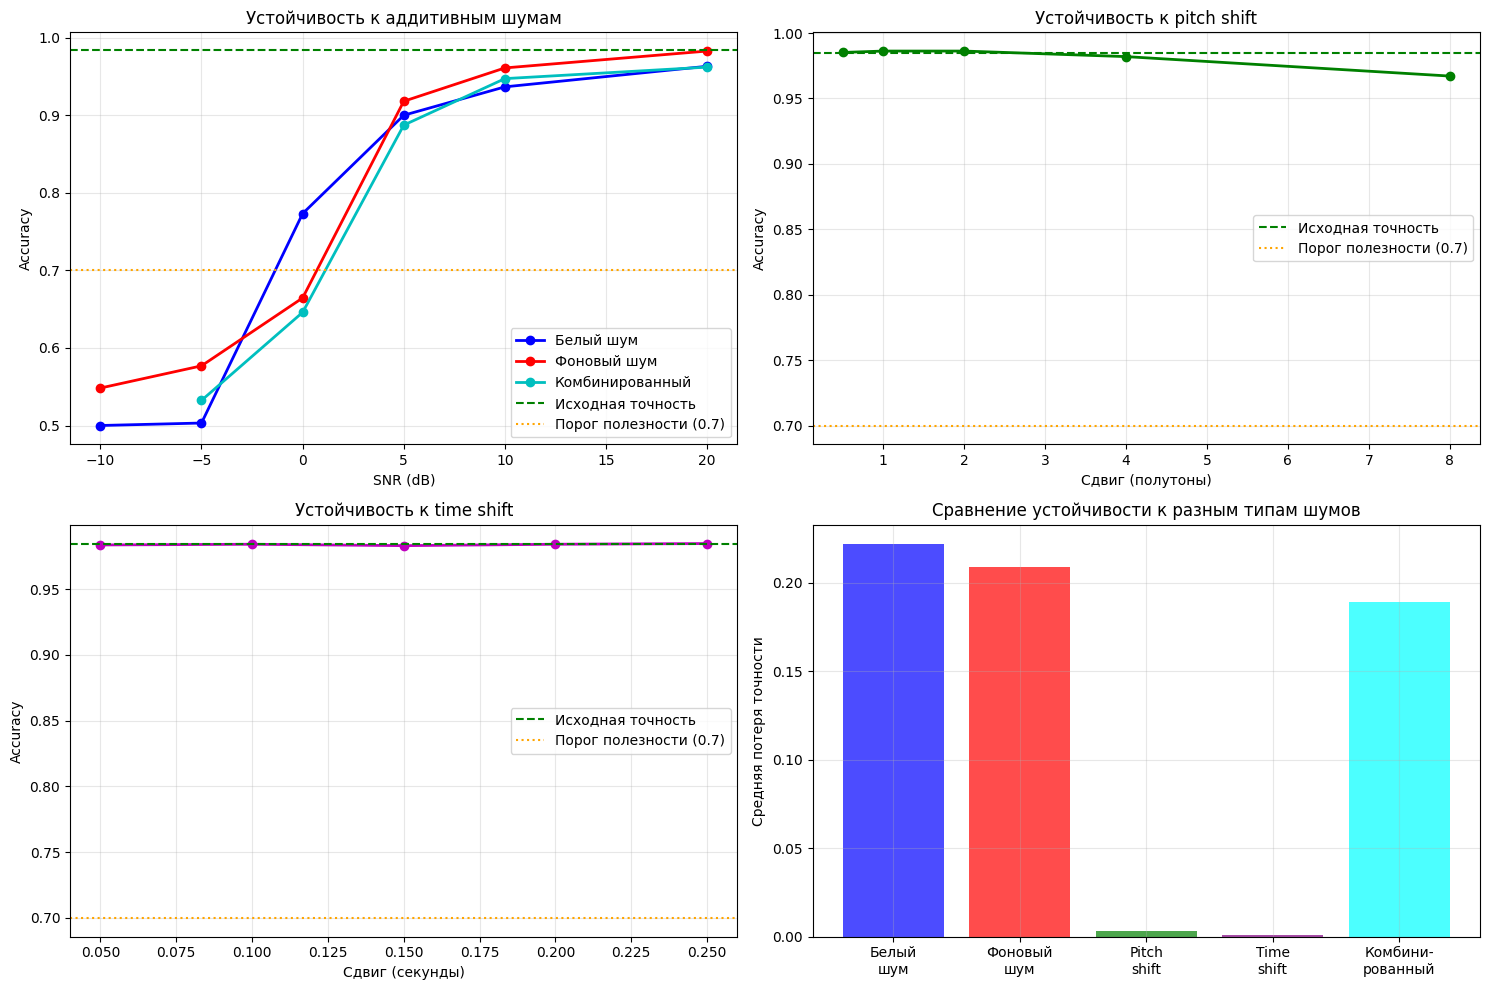


Тестирование устойчивости к шуму завершено.
✅ Модель успешно сохранена!
📊 Метрики: Accuracy = 0.9846, Лучшая эпоха = 10

Работа завершена!


In [ ]:
# -*- coding: utf-8 -*-
"""Improved Drone Detection Model"""

!pip install torchmetrics
!pip install moviepy pydub
import torch as pt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import torchmetrics
import librosa
import numpy as np
import matplotlib.pyplot as plt
import sys
import random
import os
import time
from google.colab import drive
drive.mount('/content/drive')

# Кэширование
from joblib import Memory
cachedir = '/content/cache/'
memory = Memory(cachedir, verbose=0, compress=True)
memory.clear(warn=False)

# Для воспроизводимости результатов
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
pt.manual_seed(random_seed)
pt.cuda.manual_seed(random_seed)
pt.cuda.manual_seed_all(random_seed)
pt.backends.cudnn.deterministic = True

device = 'cuda' if pt.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Загрузка датасета
!unzip -u "drive/MyDrive/AudioDataset_Detection_Balanced.zip" -d "/content/dataset"
dataset_directory = '/content/dataset/AudioDataset_Detection_Balanced'
duration = 0.5
BATCH_SIZE = 64
NUM_EPOCHS = 18

# ФУНКЦИИ ПРЕПРОЦЕССИНГА

def normalize(waveform):
    s = waveform.astype(np.float32) - np.mean(waveform)
    std = np.std(s)
    return s / (std + 1e-8)

def enhanced_melspectrogram(waveform, sr):
    """Улучшенные мел-спектрограммы"""
    spec = librosa.feature.melspectrogram(
        y=waveform, sr=sr,
        n_fft=2048,
        hop_length=256,
        n_mels=128,
        fmin=50,
        fmax=8000,
        pad_mode='reflect'
    )
    spec = librosa.power_to_db(spec, ref=np.max, amin=1e-10)
    spec = (spec - spec.mean()) / (spec.std() + 1e-8)
    return spec

def melspectrogram(waveform, sr):
    return enhanced_melspectrogram(waveform, sr)

def preprocess_file(filename, duration):
    waveform, sr = librosa.load(filename, sr=44100, duration=duration)
    waveform = normalize(waveform)
    spec = melspectrogram(waveform, sr)
    return spec.astype(np.float32)

# ДАТАСЕТЫ И ДАТАЛОАДЕРЫ

class DroneDataset(Dataset):
    def __init__(self, dataset_dir, duration, device):
        files_list = []
        for label_name, label in [("Background", 0), ("Drone", 1)]:
            folder = os.path.join(dataset_dir, label_name)
            for fname in os.listdir(folder):
                if fname.endswith(".wav"):
                    files_list.append((os.path.join(folder, fname), label))
        self.datalist = files_list
        self.duration = duration
        self.device = device

    def __len__(self):
        return len(self.datalist)

    def __getitem__(self, idx):
        spec = preprocess_file(self.datalist[idx][0], self.duration)
        spec = pt.from_numpy(spec[None, ...]).to(self.device)
        label = pt.tensor(float(self.datalist[idx][1]), dtype=pt.float32)
        return spec, label

# Создание датасетов
train_dataset = DroneDataset(os.path.join(dataset_directory, "train"), duration, device)
test_dataset = DroneDataset(os.path.join(dataset_directory, "test"), duration, device)
val_dataset = DroneDataset(os.path.join(dataset_directory, "val"), duration, device)

train_data_size = len(train_dataset)
val_data_size = len(val_dataset)
test_data_size = len(test_dataset)
print(f"Dataset sizes - Train: {train_data_size}, Val: {val_data_size}, Test: {test_data_size}")

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# АРХИТЕКТУРА МОДЕЛИ

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 8, 1),
            nn.ReLU(),
            nn.Conv2d(channels // 8, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        ca = self.channel_attention(x)
        return x * ca

class ImprovedCNNNetwork(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout_rate)
        )
        self.att1 = AttentionBlock(16)

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout_rate)
        )
        self.att2 = AttentionBlock(32)

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout_rate)
        )
        self.att3 = AttentionBlock(64)

        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)), nn.Dropout2d(dropout_rate)
        )

        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.att1(x)
        x = self.conv2(x)
        x = self.att2(x)
        x = self.conv3(x)
        x = self.att3(x)
        x = self.conv4(x)
        x = self.flatten(x)
        return self.classifier(x)

# ФУНКЦИИ ДЛЯ ОБУЧЕНИЯ

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probability_tensor = pt.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - probability_tensor)**self.gamma * BCE_loss
        return focal_loss.mean()

def compute_accuracy(y_pred, y):
    accuracy_metric = torchmetrics.classification.Accuracy(task="binary", threshold=0.5).to(device)
    return accuracy_metric(y_pred, y)

def train_and_validate(model, loss_criterion, optimizer, scheduler, epochs=5):
    history = []
    best_loss = float('inf')
    best_epoch = -1

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = train_acc = 0.0
        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = loss_criterion(outputs, labels)
            loss.backward()
            pt.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_acc += compute_accuracy(outputs, labels).item() * inputs.size(0)

        # Validation
        model.eval()
        val_loss = val_acc = 0.0
        with pt.no_grad():
            for inputs, labels in val_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze(-1)
                loss = loss_criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_acc += compute_accuracy(outputs, labels).item() * inputs.size(0)

        # Update scheduler
        scheduler.step()

        # Calculate averages
        avg_train_loss = train_loss / train_data_size
        avg_val_loss = val_loss / val_data_size
        avg_train_acc = train_acc / train_data_size
        avg_val_acc = val_acc / val_data_size

        # Save best model
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_epoch = epoch
            pt.save(model.state_dict(), f'best_model_epoch_{epoch}.pt')

        history.append([avg_train_loss, avg_val_loss, avg_train_acc, avg_val_acc])
        print(f"Epoch {epoch+1}/{epochs}: Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

    return model, history, best_epoch

# ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ МОДЕЛИ

print("Инициализация улучшенной модели с Attention...")
model = ImprovedCNNNetwork().to(device)

# Проверка архитектуры
print("Архитектура модели:")
try:
    summary(model, (1, 128, 87))
except:
    print("Не удалось вывести summary, продолжаем...")

# Инициализация оптимизатора и функции потерь
optimizer = pt.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = pt.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
loss_func = FocalLoss(alpha=0.25, gamma=2.0)

print("Начинаем обучение улучшенной модели...")
trained_model, history, best_epoch = train_and_validate(model, loss_func, optimizer, scheduler, NUM_EPOCHS)

# Загрузка лучшей модели
model.load_state_dict(pt.load(f'best_model_epoch_{best_epoch}.pt'))
best_model = model
best_model.eval()

print(f"Лучшая модель загружена из эпохи {best_epoch}")

# ОЦЕНКА МОДЕЛИ

def computeTestSetAccuracy(model, loss_criterion):
    model.eval()
    test_acc = test_loss = 0.0
    true_labels = []
    pred_labels = []

    with pt.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze(-1)
            true_labels.extend(labels.cpu().numpy().astype(int))
            pred_labels.extend((outputs > 0.5).cpu().numpy().astype(int))
            loss = loss_criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            test_acc += compute_accuracy(outputs, labels).item() * inputs.size(0)

    avg_test_acc = test_acc / test_data_size
    avg_test_loss = test_loss / test_data_size
    print(f"Test Accuracy: {avg_test_acc:.5f}, Test Loss: {avg_test_loss:.5f}")

    return avg_test_acc, true_labels, pred_labels

print("\nОценка на тестовом наборе:")
original_acc, true_labels, pred_labels = computeTestSetAccuracy(best_model, loss_func)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print('F1: {:.5f}'.format(f1_score(true_labels, pred_labels, average="binary")))
print('Accuracy: {:.5f}'.format(accuracy_score(true_labels, pred_labels)))
print('Precision: {:.5f}'.format(precision_score(true_labels, pred_labels, average="binary")))
print('Recall: {:.5f}'.format(recall_score(true_labels, pred_labels, average="binary")))

# АНАЛИЗ УСТОЙЧИВОСТИ К ШУМАМ

def add_white_noise_proper(signal, snr_db):
    """Добавление белого шума с заданным SNR в dB"""
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

def pitch_shift(signal, sr, n_steps=2.0):
    return librosa.effects.pitch_shift(y=signal, sr=sr, n_steps=n_steps)

def time_shift(signal, sr, shift_max_sec=0.1):
    shift_max = int(abs(shift_max_sec) * sr)
    if shift_max == 0:
        return signal
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(signal, shift)

def add_background_noise_proper(signal, sr, snr_db, background_files, duration):
    """Добавление фонового шума с заданным SNR в dB"""
    if not background_files:
        return signal

    bg_file = np.random.choice(background_files)
    bg_signal, _ = librosa.load(bg_file, sr=sr, duration=duration)

    if len(bg_signal) < len(signal):
        bg_signal = np.pad(bg_signal, (0, len(signal) - len(bg_signal)), mode='constant')
    else:
        bg_signal = bg_signal[:len(signal)]

    signal_power = np.mean(signal**2)
    bg_power = np.mean(bg_signal**2)

    if bg_power == 0:
        return signal

    snr_linear = 10**(snr_db / 10)
    desired_bg_power = signal_power / snr_linear
    scale_factor = np.sqrt(desired_bg_power / bg_power)

    return signal + bg_signal * scale_factor

def combined_noise(signal, sr, snr_db, background_files, pitch_steps=2.0, time_shift_sec=0.1):
    if time_shift_sec != 0.0:
        signal = time_shift(signal, sr, shift_max_sec=abs(time_shift_sec))
    if pitch_steps != 0.0:
        signal = pitch_shift(signal, sr, n_steps=abs(pitch_steps))
    signal = add_white_noise_proper(signal, snr_db)
    if background_files and len(background_files) > 0:
        signal = add_background_noise_proper(signal, sr, snr_db, background_files, len(signal)/sr)
    return signal

# Загрузка фоновых файлов
background_files = []
bg_dir = os.path.join(dataset_directory, "train", "Background")
for fname in os.listdir(bg_dir):
    if fname.endswith(".wav"):
        background_files.append(os.path.join(bg_dir, fname))

class NoisyDroneDataset(Dataset):
    def __init__(self, original_dataset, noise_type, noise_param, sr=44100):
        self.orig = original_dataset
        self.noise_type = noise_type
        self.noise_param = noise_param
        self.sr = sr
        self.bg_files = background_files

    def __len__(self):
        return len(self.orig)

    def __getitem__(self, idx):
        path, label = self.orig.datalist[idx]
        clean_wave, _ = librosa.load(path, sr=self.sr, duration=duration)
        clean_wave = normalize(clean_wave)

        if self.noise_type == 'white':
            noisy_wave = add_white_noise_proper(clean_wave, self.noise_param)
        elif self.noise_type == 'time_shift':
            noisy_wave = time_shift(clean_wave, self.sr, shift_max_sec=self.noise_param)
        elif self.noise_type == 'background':
            noisy_wave = add_background_noise_proper(clean_wave, self.sr, self.noise_param, self.bg_files, duration)
        elif self.noise_type == 'pitch_shift':
            noisy_wave = pitch_shift(clean_wave, self.sr, n_steps=self.noise_param)
        elif self.noise_type == 'combined':
            pitch_steps = abs(self.noise_param) * 0.4
            time_shift_sec = abs(self.noise_param) * 0.01
            noisy_wave = combined_noise(clean_wave, self.sr, self.noise_param, self.bg_files, pitch_steps, time_shift_sec)
        else:
            raise ValueError(f"Unknown noise type: {self.noise_type}")

        spec = melspectrogram(noisy_wave, self.sr).astype(np.float32)
        spec = pt.from_numpy(spec[None, ...]).to(device)
        label = pt.tensor(float(label), dtype=pt.float32)
        return spec, label

def test_model_on_noisy_data(model, test_dataset, noise_type, noise_level):
    noisy_ds = NoisyDroneDataset(test_dataset, noise_type, noise_level)
    loader = DataLoader(noisy_ds, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    true, pred = [], []
    with pt.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            out = model(inputs).squeeze(-1)
            preds = (out > 0.5).float().cpu().numpy()
            true.extend(labels.numpy().astype(int))
            pred.extend(preds.astype(int))
    return accuracy_score(true, pred)

def calculate_robustness_metrics(original_acc, noisy_accuracies, noise_params):
    accuracy_drop = [original_acc - acc for acc in noisy_accuracies]
    robustness_threshold = None
    for i, acc in enumerate(noisy_accuracies):
        if acc < 0.7:
            robustness_threshold = noise_params[i]
            break
    return {
        'accuracy_drop': accuracy_drop,
        'robustness_threshold': robustness_threshold,
        'mean_accuracy_drop': np.mean(accuracy_drop)
    }

# Уровни шума для тестирования
WHITE_NOISE_LEVELS = [20, 10, 5, 0, -5, -10]
BACKGROUND_NOISE_LEVELS = [20, 10, 5, 0, -5, -10]
PITCH_LEVELS = [0.5, 1, 2, 4, 8]
TIME_SHIFT_LEVELS = [0.05, 0.1, 0.15, 0.2, 0.25]
COMBINED_LEVELS = [20, 10, 5, 0, -5]

print(f"\n=== Оригинал: Accuracy = {original_acc:.5f} ===")

print("\n" + "="*80)
print(f"{'Тип шума':<15} {'Параметр':<10} {'Accuracy':<12} {'Потеря Accuracy':<15}")
print("-"*80)

# Тестирование на разных типах шумов
noise_results = {}

for noise_type, levels in [('white', WHITE_NOISE_LEVELS),
                          ('background', BACKGROUND_NOISE_LEVELS),
                          ('pitch_shift', PITCH_LEVELS),
                          ('time_shift', TIME_SHIFT_LEVELS),
                          ('combined', COMBINED_LEVELS)]:

    accuracies = []
    for level in levels:
        acc = test_model_on_noisy_data(best_model, test_dataset, noise_type, level)
        accuracies.append(acc)
        loss = original_acc - acc
        param_str = f'{level} dB' if noise_type in ['white', 'background', 'combined'] else f'{level} st' if noise_type == 'pitch_shift' else f'{level}s'
        print(f"{noise_type:<15} {param_str:<10} {acc:<12.5f} {loss:<15.5f}")

    noise_results[noise_type] = accuracies
    metrics = calculate_robustness_metrics(original_acc, accuracies, levels)
    print(f"Порог устойчивости к {noise_type}: {metrics['robustness_threshold']}")

# Визуализация результатов
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(WHITE_NOISE_LEVELS, noise_results['white'], 'bo-', label='Белый шум', linewidth=2)
plt.plot(BACKGROUND_NOISE_LEVELS, noise_results['background'], 'ro-', label='Фоновый шум', linewidth=2)
plt.plot(COMBINED_LEVELS, noise_results['combined'], 'co-', label='Комбинированный', linewidth=2)
plt.axhline(y=original_acc, color='g', linestyle='--', label='Исходная точность')
plt.axhline(y=0.7, color='orange', linestyle=':', label='Порог полезности (0.7)')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Устойчивость к аддитивным шумам')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(PITCH_LEVELS, noise_results['pitch_shift'], 'go-', linewidth=2)
plt.axhline(y=original_acc, color='g', linestyle='--', label='Исходная точность')
plt.axhline(y=0.7, color='orange', linestyle=':', label='Порог полезности (0.7)')
plt.xlabel('Сдвиг (полутоны)')
plt.ylabel('Accuracy')
plt.title('Устойчивость к pitch shift')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(TIME_SHIFT_LEVELS, noise_results['time_shift'], 'mo-', linewidth=2)
plt.axhline(y=original_acc, color='g', linestyle='--', label='Исходная точность')
plt.axhline(y=0.7, color='orange', linestyle=':', label='Порог полезности (0.7)')
plt.xlabel('Сдвиг (секунды)')
plt.ylabel('Accuracy')
plt.title('Устойчивость к time shift')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
losses = [np.mean([original_acc - acc for acc in noise_results[nt]]) for nt in ['white', 'background', 'pitch_shift', 'time_shift', 'combined']]
types = ['Белый\nшум', 'Фоновый\nшум', 'Pitch\nshift', 'Time\nshift', 'Комбини-\nрованный']
plt.bar(types, losses, color=['blue', 'red', 'green', 'purple', 'cyan'], alpha=0.7)
plt.ylabel('Средняя потеря точности')
plt.title('Сравнение устойчивости к разным типам шумов')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('robustness_analysis_detection.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nТестирование устойчивости к шуму завершено.")

# СОХРАНЕНИЕ МОДЕЛИ

def save_model_complete(model, best_epoch, original_acc, history, model_name="drone_detection_model"):
    pt.save(model.state_dict(), f'{model_name}_weights.pth')

    checkpoint = {
        'epoch': best_epoch,
        'model_state_dict': model.state_dict(),
        'best_accuracy': original_acc,
        'training_history': history,
        'model_architecture': 'ImprovedCNNNetwork'
    }
    pt.save(checkpoint, f'{model_name}_checkpoint.pth')

    print(f"Модель успешно сохранена!")
    print(f"Метрики: Accuracy = {original_acc:.4f}, Лучшая эпоха = {best_epoch}")

save_model_complete(best_model, best_epoch, original_acc, history)

print("\nРабота завершена!")

In [ ]:

# БЛОК АНАЛИЗА ВИДЕО ЧЕРЕЗ АУДИО

def extract_audio_from_video(video_path, output_audio_path):
    """Извлечение аудиодорожки из видео"""
    try:
        from moviepy.editor import VideoFileClip
        video = VideoFileClip(video_path)
        audio = video.audio
        audio.write_audiofile(output_audio_path, verbose=False, logger=None)
        video.close()
        return True
    except Exception as e:
        print(f"Ошибка извлечения аудио: {e}")
        return False

def analyze_audio_for_drones(audio_path, model, duration=0.5, overlap=0.25):
    """
    Анализ аудиофайла на наличие дронов с скользящим окном
    """
    # Загружаем аудио
    audio, sr = librosa.load(audio_path, sr=44100)

    # Параметры окон
    window_size = int(duration * sr)
    hop_size = int((duration - overlap) * sr)

    results = []
    timestamps = []

    # Обрабатываем аудио окнами
    for start in range(0, len(audio) - window_size, hop_size):
        end = start + window_size
        audio_chunk = audio[start:end]

        # Препроцессинг
        audio_chunk = normalize(audio_chunk)
        spec = melspectrogram(audio_chunk, sr).astype(np.float32)
        spec = pt.from_numpy(spec[None, None, ...]).to(device)  # [1, 1, 64, 44]

        # Предсказание
        with pt.no_grad():
            prediction = model(spec).item()

        timestamp = start / sr
        results.append(prediction)
        timestamps.append(timestamp)

    return {
        'timestamps': timestamps,
        'predictions': results,
        'audio_length': len(audio) / sr
    }

def process_video_for_drone_detection(video_path, model, duration=0.5, overlap=0.25):
    """
    Полный пайплайн: видео -> аудио -> анализ нейросетью
    """
    # Временный файл для аудио
    temp_audio = "temp_audio.wav"

    print("Извлекаем аудио из видео...")
    if not extract_audio_from_video(video_path, temp_audio):
        return None

    print("Анализируем аудио на наличие дронов...")
    results = analyze_audio_for_drones(temp_audio, model, duration, overlap)

    import os
    if os.path.exists(temp_audio):
        os.remove(temp_audio)

    return results

def plot_drone_detection_results(results, threshold=0.5):
    """
    Визуализация результатов детекции дронов во времени
    """
    timestamps = results['timestamps']
    predictions = results['predictions']

    plt.figure(figsize=(15, 8))

    # График вероятностей
    plt.subplot(2, 1, 1)
    plt.plot(timestamps, predictions, 'b-', alpha=0.7, label='Вероятность дрона')
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Порог ({threshold})')
    plt.fill_between(timestamps, 0, predictions,
                    where=[p > threshold for p in predictions],
                    color='red', alpha=0.3, label='Дрон обнаружен')
    plt.ylabel('Вероятность')
    plt.title('Детекция дронов по аудио из видео')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Бинарная детекция
    plt.subplot(2, 1, 2)
    binary_detection = [1 if p > threshold else 0 for p in predictions]
    plt.step(timestamps, binary_detection, 'r-', where='post', linewidth=2)
    plt.ylabel('Дрон (1 - да, 0 - нет)')
    plt.xlabel('Время (секунды)')
    plt.yticks([0, 1])
    plt.grid(True, alpha=0.3)

    # Статистика
    total_time = results['audio_length']
    drone_time = sum(binary_detection) * (timestamps[1] - timestamps[0])
    drone_percentage = (drone_time / total_time) * 100

    plt.figtext(0.02, 0.02,
                f"Общее время: {total_time:.1f}с | "
                f"Время с дроном: {drone_time:.1f}с ({drone_percentage:.1f}%)",
                fontsize=12, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig('video_audio_detection.png', dpi=200, bbox_inches='tight')
    plt.show()

    return drone_percentage

def smooth_predictions(predictions, window_size=5):
    """Сглаживание предсказаний скользящим средним"""
    return np.convolve(predictions, np.ones(window_size)/window_size, mode='same')

def advanced_detection_logic(predictions, timestamps, threshold=0.5, min_duration=1.0):
    """
    Продвинутая логика детекции:
    - Игнорировать короткие срабатывания
    - Объединять близкие детекции
    """
    smoothed = smooth_predictions(predictions)
    binary = [1 if p > threshold else 0 for p in smoothed]
    segments = []
    in_segment = False
    segment_start = 0

    for i, (ts, det) in enumerate(zip(timestamps, binary)):
        if det and not in_segment:
            in_segment = True
            segment_start = ts
        elif not det and in_segment:
            in_segment = False
            segment_end = ts
            duration = segment_end - segment_start
            if duration >= min_duration:
                segments.append((segment_start, segment_end, duration))

    return segments


БЛОК АНАЛИЗА ВИДЕО ЧЕРЕЗ АУДИО
Пытаемся проанализировать видео: /content/drive/MyDrive/video/drone_video_plane.mp4
Извлекаем аудио из видео...
Анализируем аудио на наличие дронов...


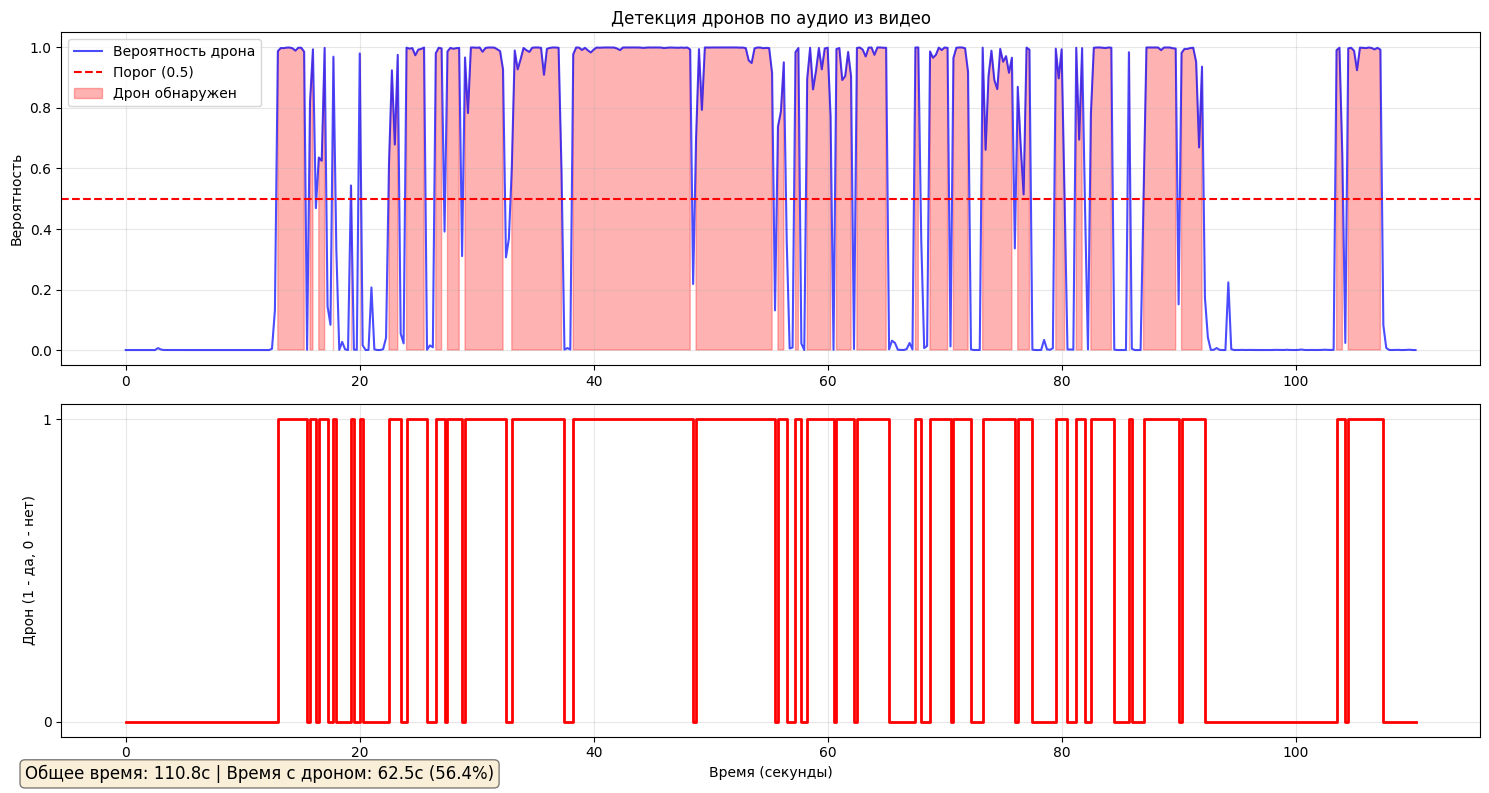

РЕЗУЛЬТАТ: Дрон обнаружен в 56.4% времени видео
Найдено сегментов с дроном: 10
  Сегмент 1: 13.0с - 17.0с (длительность: 4.0с)
  Сегмент 2: 22.8с - 25.8с (длительность: 3.0с)
  Сегмент 3: 26.5с - 37.5с (длительность: 11.0с)
  Сегмент 4: 38.2с - 56.5с (длительность: 18.2с)
  Сегмент 5: 57.8с - 65.2с (длительность: 7.5с)
  Сегмент 6: 68.8с - 72.2с (длительность: 3.5с)
  Сегмент 7: 73.2с - 77.5с (длительность: 4.2с)
  Сегмент 8: 81.2с - 84.5с (длительность: 3.2с)
  Сегмент 9: 87.0с - 92.2с (длительность: 5.2с)
  Сегмент 10: 103.5с - 107.5с (длительность: 4.0с)

Анализ видео завершен!


In [ ]:

# ПРИМЕР ИСПОЛЬЗОВАНИЯ С ВИДЕО

print("\n" + "="*60)
print("БЛОК АНАЛИЗА ВИДЕО ЧЕРЕЗ АУДИО")
print("="*60)

# Загружаем обученную модель
best_model.eval()

# Анализ видео файла
video_path = "/content/drive/MyDrive/video/drone_video_plane.mp4"

try:
    print(f"Пытаемся проанализировать видео: {video_path}")
    results = process_video_for_drone_detection(video_path, best_model)

    if results:
        drone_percentage = plot_drone_detection_results(results)
        print(f"РЕЗУЛЬТАТ: Дрон обнаружен в {drone_percentage:.1f}% времени видео")

        segments = advanced_detection_logic(results['predictions'], results['timestamps'])
        print(f"Найдено сегментов с дроном: {len(segments)}")
        for i, (start, end, duration) in enumerate(segments):
            print(f"  Сегмент {i+1}: {start:.1f}с - {end:.1f}с (длительность: {duration:.1f}с)")
    else:
        print("Не удалось обработать видео")

except Exception as e:
    print(f"Ошибка при обработке видео: {e}")
    print("Требуется проверить:")
    print("1. Путь к видео файлу правильный")
    print("2. Файл существует")
    print("3. Формат видео поддерживается (mp4, avi, mov)")

print("\nАнализ видео завершен!")